# Phần 2 – Bài toán Phân lớp: Airline Passenger Satisfaction
**Nguồn dữ liệu:** Kaggle - teejmahal20/airline-passenger-satisfaction  

**Mô tả:** từ thông tin hành khách, chuyến bay và các đánh giá dịch vụ để dự đoán mức độ hài lòng của hành khách hàng không 

**Mục tiêu:** Dự đoán mức độ hài lòng hành khách (satisfied vs neutral or dissatisfied)  

**Số lượng mẫu:** 129,880 mẫu (103,904 train, 25,976 test) 

**Số lượng biến:** 25 

**Số lớp:** nhị phân (satisfied và neutral or dissatisfied) 

**Link source :** https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction/data?select=train.csv

## Cài đặt môi trường và đường dẫn dữ liệu

In [1]:
import os

_notebook_dir  = os.path.abspath('')          # thư mục chứa notebook
BASE_PATH      = os.path.abspath(os.path.join(_notebook_dir, '..', '..'))
RAW_DATA_PATH  = os.path.join(BASE_PATH, 'data', 'raw')
PROC_PATH = os.path.join(BASE_PATH, 'report', 'figures')
PROC_DATA_PATH = os.path.join(BASE_PATH, 'data', 'processed')
SRC_PATH       = os.path.join(BASE_PATH, 'code', 'Part2_Classification')


# Tạo thư mục processed nếu chưa có
os.makedirs(PROC_PATH, exist_ok=True)

# Đường dẫn đến file dữ liệu
TRAIN_PATH = os.path.join(RAW_DATA_PATH, 'train.csv')
TEST_PATH  = os.path.join(RAW_DATA_PATH, 'test.csv')
PKL_PATH   = os.path.join(PROC_DATA_PATH, 'processed_data.pkl')
INFO_PATH  = os.path.join(PROC_DATA_PATH, 'preprocessing_info.json')

# In thông tin
env_name = 'Local Machine'
print(f'Môi trường    : {env_name}')
print(f'BASE_PATH     : {BASE_PATH}')
print(f'RAW_DATA_PATH : {RAW_DATA_PATH}')
print(f'PROC_PATH: {PROC_PATH}')
print(f'SRC_PATH      : {SRC_PATH}')
print()

# Kiểm tra file dữ liệu tồn tại
for path, name in [(TRAIN_PATH, 'train.csv'), (TEST_PATH, 'test.csv')]:
    status = '✓ Tìm thấy' if os.path.exists(path) else '✗ KHÔNG TÌM THẤY'
    print(f'  {status}: {name}  tại đường dẫn  {path}')

Môi trường    : Local Machine
BASE_PATH     : d:\2025-2026 HKII\Machine Learning\Project1\Machine-Learning---Project-1-
RAW_DATA_PATH : d:\2025-2026 HKII\Machine Learning\Project1\Machine-Learning---Project-1-\data\raw
PROC_PATH: d:\2025-2026 HKII\Machine Learning\Project1\Machine-Learning---Project-1-\report\figures
SRC_PATH      : d:\2025-2026 HKII\Machine Learning\Project1\Machine-Learning---Project-1-\code\Part2_Classification

  ✓ Tìm thấy: train.csv  tại đường dẫn  d:\2025-2026 HKII\Machine Learning\Project1\Machine-Learning---Project-1-\data\raw\train.csv
  ✓ Tìm thấy: test.csv  tại đường dẫn  d:\2025-2026 HKII\Machine Learning\Project1\Machine-Learning---Project-1-\data\raw\test.csv


## Import thư viện sử dụng

In [2]:
import os, sys, json, pickle, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

TARGET = 'satisfaction'
DELAY_COLS = ['Departure Delay in Minutes', 'Arrival Delay in Minutes']

SEED = 42
np.random.seed(SEED)

# Cấu hình giao diện biểu đồ
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

print('Thư viện đã được tải thành công.')

Thư viện đã được tải thành công.


---
## 1. Data Overview - Mô tả & Làm sạch dữ liệu

### 1.1 Đọc dữ liệu

In [3]:
# Đọc dữ liệu gốc
print('Đang đọc dữ liệu...')
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(f'Kích thước dữ liệu train: {train_df.shape}')
display(train_df.head())

print(f'Kích thước dữ liệu test: {test_df.shape}')
display(test_df.head())

Đang đọc dữ liệu...
Kích thước dữ liệu train: (103904, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


Kích thước dữ liệu test: (25976, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


**Nhận xét:**
Mỗi dòng dữ liệu đại diện cho một hành khách cùng với trải nghiệm chuyến bay của họ. Dataset bao gồm các nhóm thông tin chính:
- **Thông tin cá nhân**: giới tính, độ tuổi, loại khách hàng
- **Thông tin chuyến bay**: loại chuyến bay, khoảng cách bay
- **Đánh giá chất lượng dịch vụ**: như wifi, đồ ăn, giải trí trên chuyến bay, độ thoải mái ghế ngồi, ...
- **Biến mục tiêu (target)**: satisfaction - thể hiện mức độ hài lòng của hành khách

Cột `Unnamed: 0` và `id` là index kỹ thuật, không mang giá trị dự đoán nên nhóm sẽ chọn để loại bỏ.

### 1.2 Thông tin dữ liệu train

In [4]:
print('Thông tin dữ liệu train:')
train_df.info()

Thông tin dữ liệu train:
<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  str    
 3   Customer Type                      103904 non-null  str    
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  str    
 6   Class                              103904 non-null  str    
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location            

**Nhận xét:**  
Kết quả cho thấy cả tập train và test đều có cùng cấu trúc với 25 cột.
- Phần lớn các biến là kiểu số (`int64`, `float64`), đặc biệt là các biến đánh giá dịch vụ (thang điểm 0-5)
- Có 5 biến dạng phân loại (`object`), bao gồm: `Gender`, `Customer Type`, `Type of Travel`, `Class` và `satisfaction`

Ta thấy cấu trúc dữ liệu rõ ràng,các kiểu dữ liệu phù hợp và không cần chuyển đổi kiểu đáng kể.

## Cột dữ liệu và ý nghĩa

### Đinh nghĩa các cột dữ liệu

Ý nghĩa của từng cột trong dataset được trình bày trong bảng dưới đây.

| Tên cột | Định nghĩa |
|------------|------------|
| Unnamed: 0 | Cột chỉ số phát sinh khi lưu dữ liệu ra CSV, không mang ý nghĩa phân tích thực tế |
| id | Mã định danh của từng hành khách / bản ghi |
| Gender | Giới tính của hành khách |
| Customer Type | Loại khách hàng (trung thành/không trung thành) |
| Age | Độ tuổi của hành khách |
| Type of Travel | Mục đích chuyến đi (công tác/cá nhân) |
| Class | Hạng ghế của hành khách (Business/Eco/Eco Plus) |
| Flight Distance | Khoảng cách chuyến bay |
| Inflight wifi service | Mức độ hài lòng về chất lượng dịch vụ wifi trên chuyến bay (0:Not Applicable, 1-5) |
| Departure/Arrival time convenient | Mức độ hài lòng về sự thuận tiện của thời gian khởi hành/đến nơi |
| Ease of Online booking | Mức độ hài lòng về sự dễ dàng của quá trình đặt vé trực tuyến |
| Gate location | Mức độ hài lòng về vị trí cổng ra máy bay |
| Food and drink | Mức độ hài lòng về đồ ăn và thức uống |
| Online boarding | Mức độ hài lòng về trải nghiệm làm thủ tục/lên máy bay trực tuyến |
| Seat comfort | Mức độ hài lòng về độ thoải mái của ghế ngồi |
| Inflight entertainment | Mức độ hài lòng về dịch vụ giải trí trên chuyến bay |
| On-board service | Mức độ hài lòng về chất lượng phục vụ trên máy bay |
| Leg room service | Mức độ hài lòng về không gian để chân |
| Baggage handling | Mức độ hài lòng về chất lượng xử lý hành lý |
| Checkin service | Mức độ hài lòng về dịch vụ check-in |
| Inflight service | Mức độ hài lòng về dịch vụ trên chuyến bay |
| Cleanliness | Mức độ hài lòng về độ sạch sẽ |
| Departure Delay in Minutes | Số phút khởi hành trễ |
| Arrival Delay in Minutes | Số phút đến nơi trễ |
| satisfaction | Mức độ hài lòng của hành khách |


### Các cột quan trọng cho EDA và mô hình hóa

Phần lớn các cột trong dataset đều hữu ích cho phân tích thăm dò dữ liệu (EDA) và mô hình hóa. Đặc biệt, các nhóm cột sau có liên hệ trực tiếp với mức độ hài lòng của hành khách:

- **Biến mục tiêu:**  
  `satisfaction`

- **Thông tin khách hàng:**  
  `Gender`, `Customer Type`, `Age`

- **Thông tin chuyến đi và chuyến bay:**  
  `Type of Travel`, `Class`, `Flight Distance`

- **Các biến đánh giá chất lượng dịch vụ:**  
  `Inflight wifi service`, `Departure/Arrival time convenient`,  
  `Ease of Online booking`, `Gate location`, `Food and drink`,  
  `Online boarding`, `Seat comfort`, `Inflight entertainment`,  
  `On-board service`, `Leg room service`, `Baggage handling`,  
  `Checkin service`, `Inflight service`, `Cleanliness`

- **Các biến về độ trễ chuyến bay:**  
  `Departure Delay in Minutes`, `Arrival Delay in Minutes`

Nhóm biến dịch vụ đặc biệt quan trọng vì chúng phản ánh trực tiếp trải nghiệm của hành khách và có thể có mối liên hệ đáng kể với biến `satisfaction`

### Các cột cân nhắc loại bỏ

Một số cột có thể được xem xét loại bỏ trong bước tiền xử lý:

- `Unnamed: 0`:  
  Đây là cột chỉ số dư thừa được sinh ra trong quá trình xuất dữ liệu, không mang thông tin thực tế và không có giá trị phân tích.

- `id`:  
  Đây là mã định danh của từng bản ghi. Cột này chỉ dùng để phân biệt quan sát, không phản ánh đặc điểm hành khách hay chất lượng dịch vụ, do đó không hữu ích cho EDA hoặc mô hình dự đoán.

Hai cột trên nên được loại bỏ trước khi thực hiện thống kê mô tả, tính toán tương quan, và xây dựng mô hình.

**Nhận xét:** Tập Train và Test đều sạch, không chứa dòng trùng lặp (duplicates) hay dòng trống hoàn toàn.

#### Loại bỏ các cột không cần thiết

In [5]:
cols_to_drop = ["Unnamed: 0", "id"]

train_df = train_df.drop(columns=cols_to_drop, errors="ignore")
test_df = test_df.drop(columns=cols_to_drop, errors="ignore")

print("Đã xóa thành công")

Đã xóa thành công


### 1.3 Kiểm tra dữ liệu
- Kiểm tra dòng trùng lặp
- Kiểm tra dòng rỗng hoàn toàn

In [6]:
print("DÒNG TRÙNG LẶP")
print("Số dòng trùng lặp trong train:", train_df.duplicated().sum())
print("Số dòng trùng lặp trong test:", test_df.duplicated().sum())
print("\n")
print("DÒNG RỖNG HOÀN TOÀN")
print("Số dòng dữ liệu rỗng trong train:", train_df.isna().all(axis=1).sum())
print("Số dòng dữ liệu rỗng trong test:", test_df.isna().all(axis=1).sum())

DÒNG TRÙNG LẶP
Số dòng trùng lặp trong train: 0
Số dòng trùng lặp trong test: 0


DÒNG RỖNG HOÀN TOÀN
Số dòng dữ liệu rỗng trong train: 0
Số dòng dữ liệu rỗng trong test: 0


**Nhận xét:** Không tồn tại dòng nào trùng lặp và hoàn toàn rỗng trong bộ dữ liệu

### 1.4 Thống kê mô tả (mean, std, min, max, tứ vị)

In [7]:
print("Mô tả dữ liệu train:")
display(train_df.describe().T.round(3))
print("Mô tả dữ liệu test:")
display(test_df.describe().T.round(3))

Mô tả dữ liệu train:


,count,mean,std,min,25%,50%,75%,max
Age,103904.0,39.380,15.115,7.0,27.0,40.0,51.0,85.0
Flight Distance,103904.0,1189.448,997.147,31.0,414.0,843.0,1743.0,4983.0
Inflight wifi service,103904.0,2.730,1.328,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,103904.0,3.060,1.525,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,103904.0,2.757,1.399,0.0,2.0,3.0,4.0,5.0
Gate location,103904.0,2.977,1.278,0.0,2.0,3.0,4.0,5.0
Food and drink,103904.0,3.202,1.330,0.0,2.0,3.0,4.0,5.0
Online boarding,103904.0,3.250,1.350,0.0,2.0,3.0,4.0,5.0
Seat comfort,103904.0,3.439,1.319,0.0,2.0,4.0,5.0,5.0
Inflight entertainment,103904.0,3.358,1.333,0.0,2.0,4.0,4.0,5.0


Mô tả dữ liệu test:


,count,mean,std,min,25%,50%,75%,max
Age,25976.0,39.621,15.136,7.0,27.0,40.0,51.0,85.0
Flight Distance,25976.0,1193.788,998.684,31.0,414.0,849.0,1744.0,4983.0
Inflight wifi service,25976.0,2.725,1.335,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,25976.0,3.047,1.533,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,25976.0,2.757,1.413,0.0,2.0,3.0,4.0,5.0
Gate location,25976.0,2.977,1.282,1.0,2.0,3.0,4.0,5.0
Food and drink,25976.0,3.215,1.332,0.0,2.0,3.0,4.0,5.0
Online boarding,25976.0,3.262,1.356,0.0,2.0,4.0,4.0,5.0
Seat comfort,25976.0,3.449,1.320,1.0,2.0,4.0,5.0,5.0
Inflight entertainment,25976.0,3.358,1.338,0.0,2.0,4.0,4.0,5.0


**Nhận xét:**  
- Từ bảng thống kê mô tả, ta thấy phân phối của các biến trong tập train và test khá tương đồng với các giá trị mean, median và độ lệch chuẩn gần như giống nhau. Điều này cho thấy hai tập dữ liệu có tính nhất quán tốt và không xuất hiện hiện tượng lệch phân phối.
- Các biến đánh giá dịch vụ chủ yếu có giá trị trung bình nằm trong khoảng từ 3 đến 4, cho thấy mức độ hài lòng của hành khách ở mức trung bình đến khá.
- Đối với các biến độ trễ (`Departure Delay in Minutes` và `Arrival Delay in Minutes`), median bằng 0 nhưng giá trị tối đa rất lớn, cho thấy dữ liệu bị lệch phải và tồn tại các giá trị ngoại lai.

### 1.5 Kiểm tra tính toàn vẹn dữ liệu
Để đánh giá chất lượng dữ liệu, số lượng giá trị thiếu (missing values) trong từng cột được kiểm tra cho cả tập train và test.

In [8]:
missing_train = train_df.isnull().sum()
missing_test  = test_df.isnull().sum()

print('Những giá trị bị thiếu trong tập train:')
mv = missing_train[missing_train > 0]
if len(mv):
    display(mv.to_frame('count').assign(pct=lambda d: (d['count']/len(train_df)*100).round(3)))
else:
    print('Không có missing values.')

print()
print('Những giá trị bị thiếu trong tập test:')
mv2 = missing_test[missing_test > 0]
if len(mv2):
    display(mv2.to_frame('count').assign(pct=lambda d: (d['count']/len(test_df)*100).round(3)))
else:
    print('Không có missing values.')
print('\n')
print('Phân phối biến mục tiêu: ')
print(train_df['satisfaction'].value_counts())
print(f"Tỉ lệ mất cân bằng: {train_df['satisfaction'].value_counts(normalize=True).round(3).to_dict()}")
print()

# Giá trị phân biệt của các cột categorical
cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']
for col in cat_cols:
    print(f"{col}: {train_df[col].unique().tolist()}")

Những giá trị bị thiếu trong tập train:


,count,pct
Arrival Delay in Minutes,310,0.298



Những giá trị bị thiếu trong tập test:


,count,pct
Arrival Delay in Minutes,83,0.32




Phân phối biến mục tiêu: 
satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64
Tỉ lệ mất cân bằng: {'neutral or dissatisfied': 0.567, 'satisfied': 0.433}

Gender: ['Male', 'Female']
Customer Type: ['Loyal Customer', 'disloyal Customer']
Type of Travel: ['Personal Travel', 'Business travel']
Class: ['Eco Plus', 'Business', 'Eco']
satisfaction: ['neutral or dissatisfied', 'satisfied']


**Nhận xét:** Phân tích missing values cho thấy chỉ có biến `Arrival Delay in Minutes` chứa giá trị thiếu, với số lượng nhỏ so với tổng số quan sát.  

Do biến này có phân phối lệch và chứa outliers, phương pháp điền giá trị trung vị (median) được lựa chọn để xử lý missing values, nhằm đảm bảo tính ổn định và hạn chế ảnh hưởng của các giá trị cực đoan.  

#### Xử lý Missing values
Giá trị thiếu sẽ được xử lý riêng cho từng tập dữ liệu (train và test) để tránh rò rỉ thông tin (data leakage).

In [9]:
# Fit median trên train ONLY và áp dụng cho cả test để tránh Data Leakage
MEDIAN_ARRIVAL = train_df['Arrival Delay in Minutes'].median()

train_df['Arrival Delay in Minutes'] = train_df['Arrival Delay in Minutes'].fillna(MEDIAN_ARRIVAL)
test_df['Arrival Delay in Minutes']  = test_df['Arrival Delay in Minutes'].fillna(MEDIAN_ARRIVAL)

print(f'Median Arrival Delay (tính từ train) = {MEDIAN_ARRIVAL} phút')
print(f'Missing còn lại – Train: {train_df.isnull().sum().sum()} | Test: {test_df.isnull().sum().sum()}')
print('✓ Tất cả giá trị thiếu đã được xử lý.')

Median Arrival Delay (tính từ train) = 0.0 phút
Missing còn lại – Train: 0 | Test: 0
✓ Tất cả giá trị thiếu đã được xử lý.


### 1.6 Phân phối các biến phân loại

In [10]:
cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']
for col in cat_cols:
    print(f'{col}:  {train_df[col].unique().tolist()}')
    vals = train_df[col].value_counts(normalize=True).map(lambda x: f'{x:.1%}')
    print(f'  {vals.to_dict()}')
    print()

Gender:  ['Male', 'Female']
  {'Female': '50.7%', 'Male': '49.3%'}

Customer Type:  ['Loyal Customer', 'disloyal Customer']
  {'Loyal Customer': '81.7%', 'disloyal Customer': '18.3%'}

Type of Travel:  ['Personal Travel', 'Business travel']
  {'Business travel': '69.0%', 'Personal Travel': '31.0%'}

Class:  ['Eco Plus', 'Business', 'Eco']
  {'Business': '47.8%', 'Eco': '45.0%', 'Eco Plus': '7.2%'}

satisfaction:  ['neutral or dissatisfied', 'satisfied']
  {'neutral or dissatisfied': '56.7%', 'satisfied': '43.3%'}



**Nhận xét:**
- Biến `Gender` có tỷ lệ khá cân bằng giữa nam và nữ: với nam chiếm 49.3% và nữ chiếm 50.7%.
- Biến `Customer Type` cho thấy phần lớn khách hàng là trung thành (81.7%), trong khi chỉ có 18.3% là khách hàng không trung thành.
- Biến `Type of Travel` cho thấy đa số hành khách đi vì công việc (69.0%), trong khi chỉ có 31.0% đi vì lý do cá nhân.
- Biến `Class` cho thấy phần lớn hành khách đi hạng phổ thông (Economy) với 47.8%, trong khi chỉ có 45.0% đi hạng phổ thông đặc biệt (Economy Plus) và 7.2% đi hạng thương gia (Business).
- Biến mục tiêu `satisfaction` cho thấy 43.3% hành khách hài lòng, trong khi 56.7% không hài lòng hoặc trung lập. Điều này có thể ảnh hưởng đến hiệu suất của mô hình phân lớp, đặc biệt là đối với các thuật toán nhạy cảm với sự mất cân bằng lớp. Các kỹ thuật như oversampling, undersampling hoặc sử dụng các thuật toán phân lớp có khả năng xử lý mất cân bằng có thể được xem xét trong bước mô hình hóa. 

## 2. PHÂN TÍCH KHÁM PHÁ (EDA)
### 2.1 Phân bố biến mục tiêu (Target distribution)

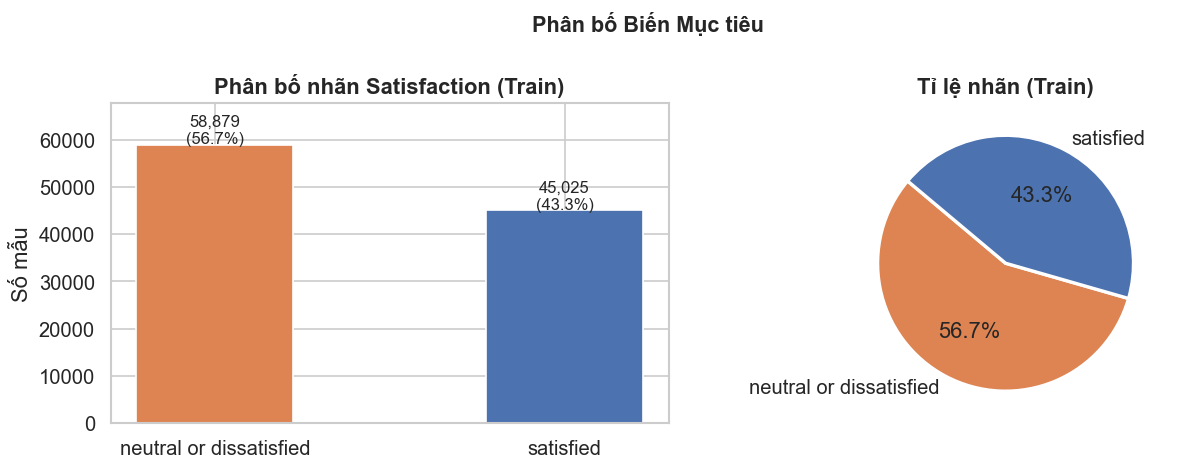

Tỉ lệ majority/minority: 1.308:1


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
counts = train_df[TARGET].value_counts()
colors = ['#DD8452', '#4C72B0']

# Bar chart
axes[0].bar(counts.index, counts.values, color=colors, width=0.45, edgecolor='white')
for lbl, cnt in zip(counts.index, counts.values):
    axes[0].text(counts.index.get_loc(lbl), cnt + 300,
                 f'{cnt:,}\n({cnt/len(train_df):.1%})', ha='center', fontsize=10)
axes[0].set_title('Phân bố nhãn Satisfaction (Train)', fontweight='bold')
axes[0].set_ylabel('Số mẫu')
axes[0].set_ylim(0, max(counts.values) * 1.15)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Tỉ lệ nhãn (Train)', fontweight='bold')

plt.suptitle('Phân bố Biến Mục tiêu', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROC_PATH, '01_target_distribution.png'), bbox_inches='tight')
plt.show()

ratio = counts.max() / counts.min()
print(f'Tỉ lệ majority/minority: {ratio:.3f}:1')

**Nhận xét:**  
- `neutral or dissatisfied`: ~56.7% | `satisfied`: ~43.3%  
- Tỉ lệ mất cân bằng ≈ **1.31:1** → mất cân bằng nhẹ, không cần SMOTE.  
- Nên dùng `class_weight='balanced'` trong các model để tránh bias về phía lớp đa số.

### 2.2 Phân bố biến số (Histogram & Boxplot)

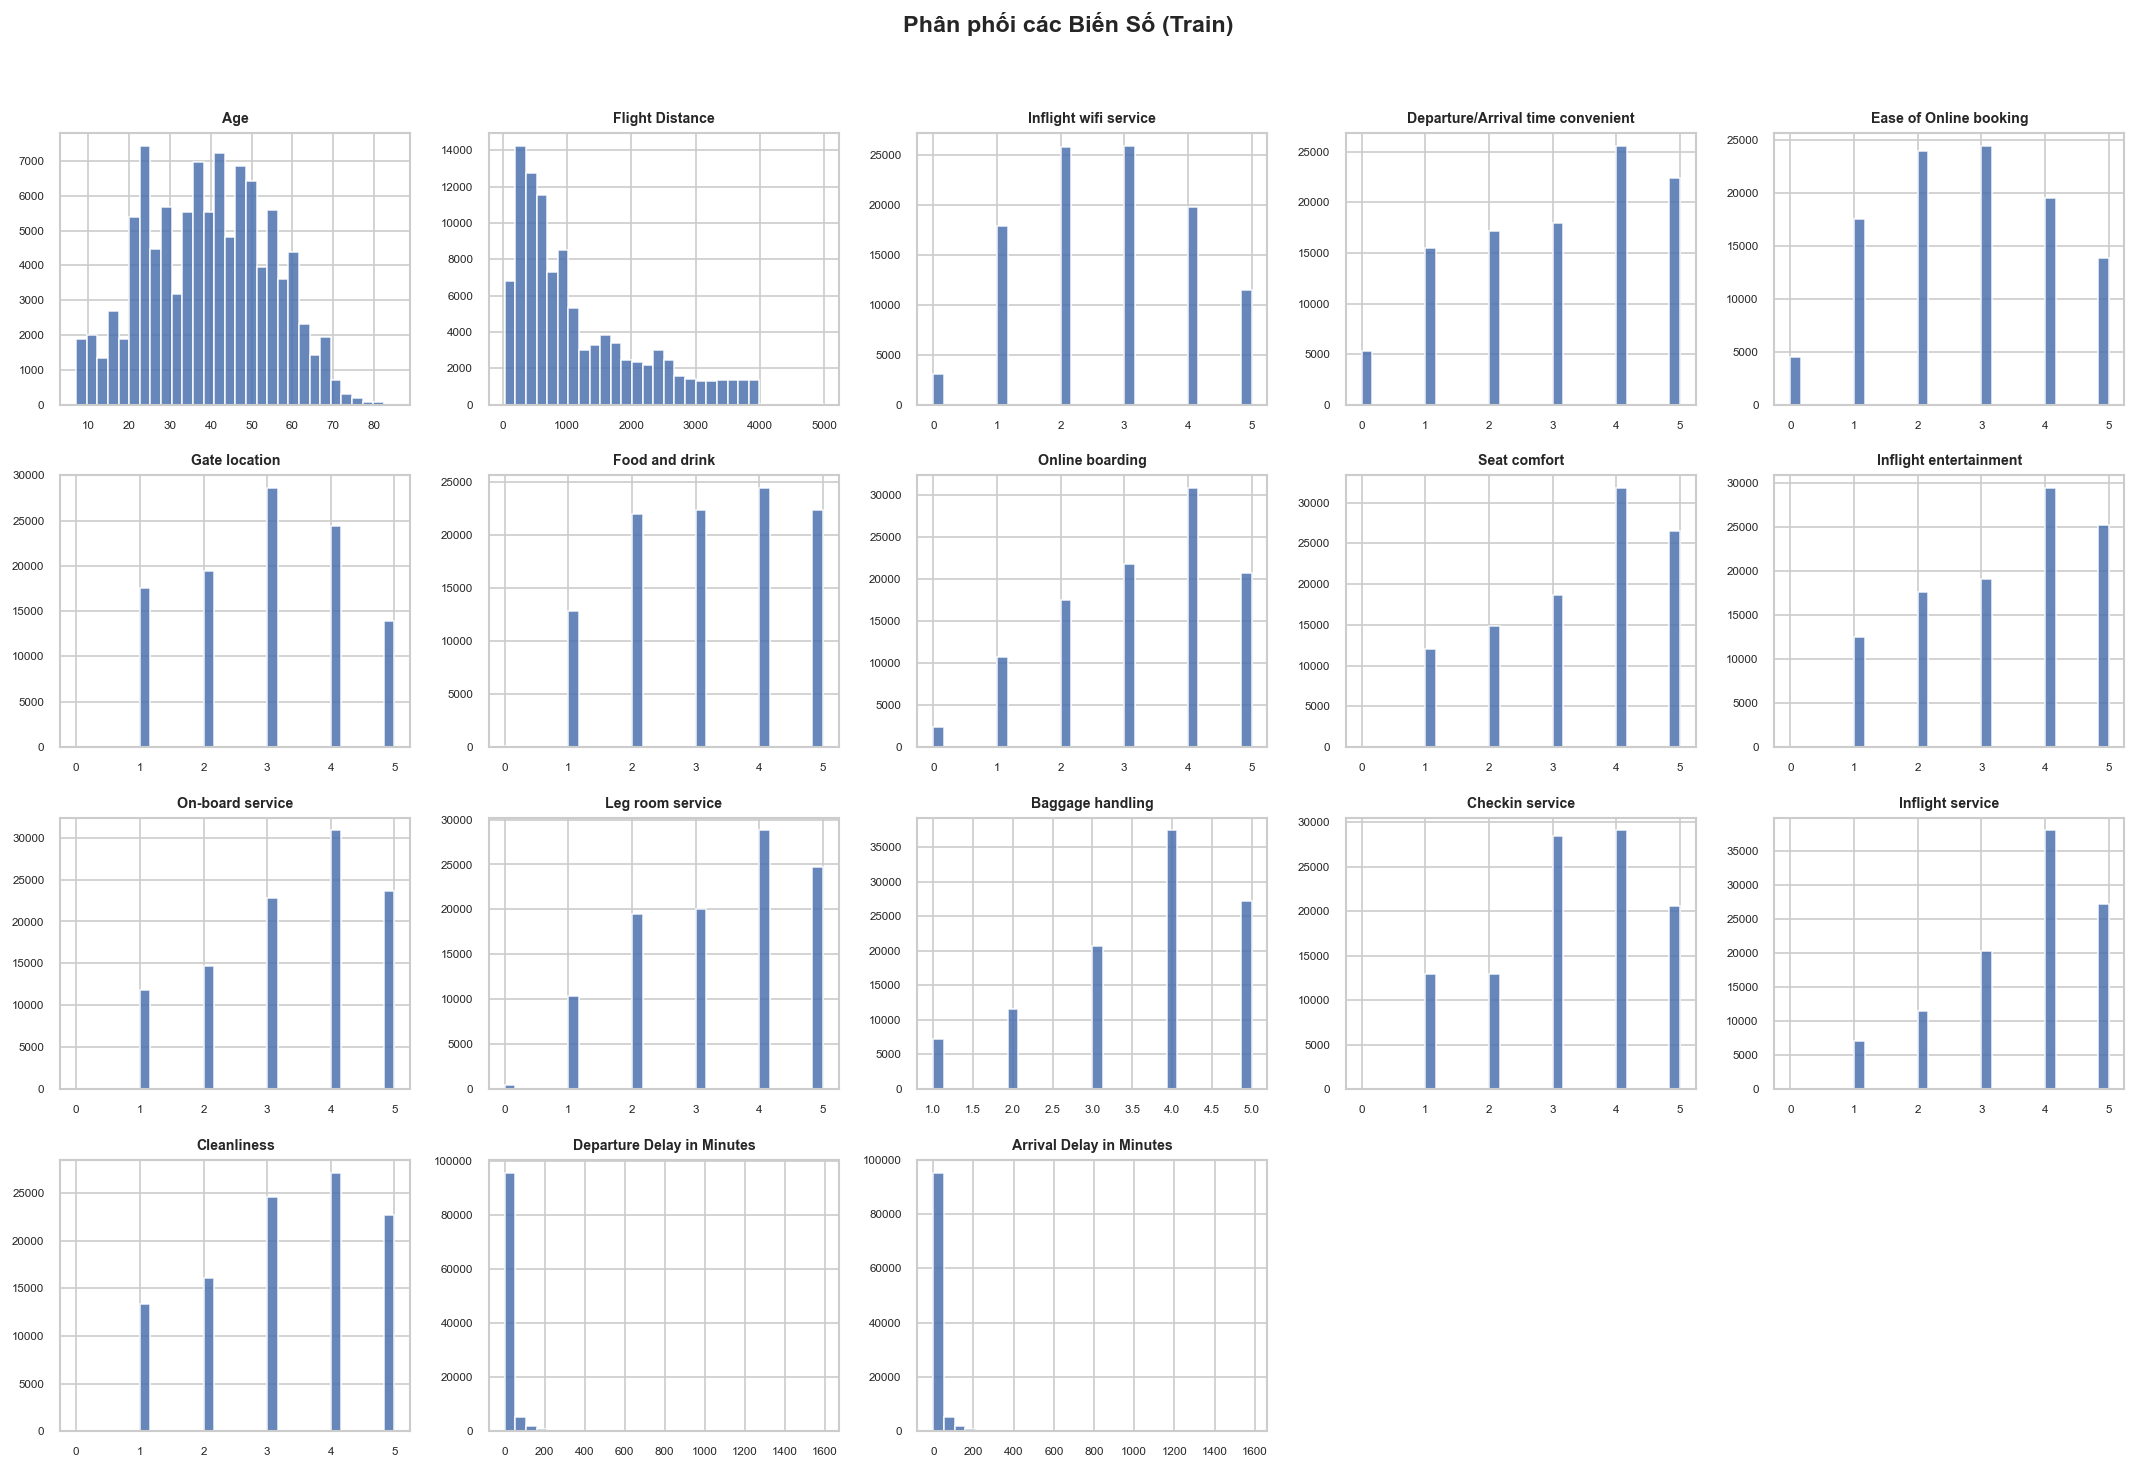

In [12]:
num_cols = train_df.select_dtypes(include=np.number).columns.tolist()

# 2. Tự động tính toán số hàng (mỗi hàng 5 biểu đồ)
n_cols = 5
n_rows = math.ceil(len(num_cols) / n_cols)

# 3. Khởi tạo biểu đồ với số hàng động
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3)) # Chiều cao tự điều chỉnh
axes = axes.flatten()

# 4. Vẽ biểu đồ
for i, col in enumerate(num_cols):
    axes[i].hist(train_df[col].dropna(), bins=30, color='#4C72B0', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=8.5, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=7)

# 5. Ẩn các trục thừa (nếu tổng số cột không chia hết cho 5)
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Phân phối các Biến Số (Train)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
# Đảm bảo thư mục PROC_PATH đã tồn tại trước khi save
plt.savefig(os.path.join(PROC_PATH, '02_histograms.png'), bbox_inches='tight')
plt.show()

**Nhận xét:**
- Các biến delay có phân phối lệch phải và chứa nhiều outliers lớn.  
- Điều này có thể ảnh hưởng đến các mô hình tuyến tính như Logistic Regression.  
- Do đó, áp dụng log-transform để giảm skewness là cần thiết.  
- Ngoài ra, có thể cân nhắc các mô hình ít nhạy với outliers như Random Forest.

### 2.3 Boxplot - Phát hiện outlier

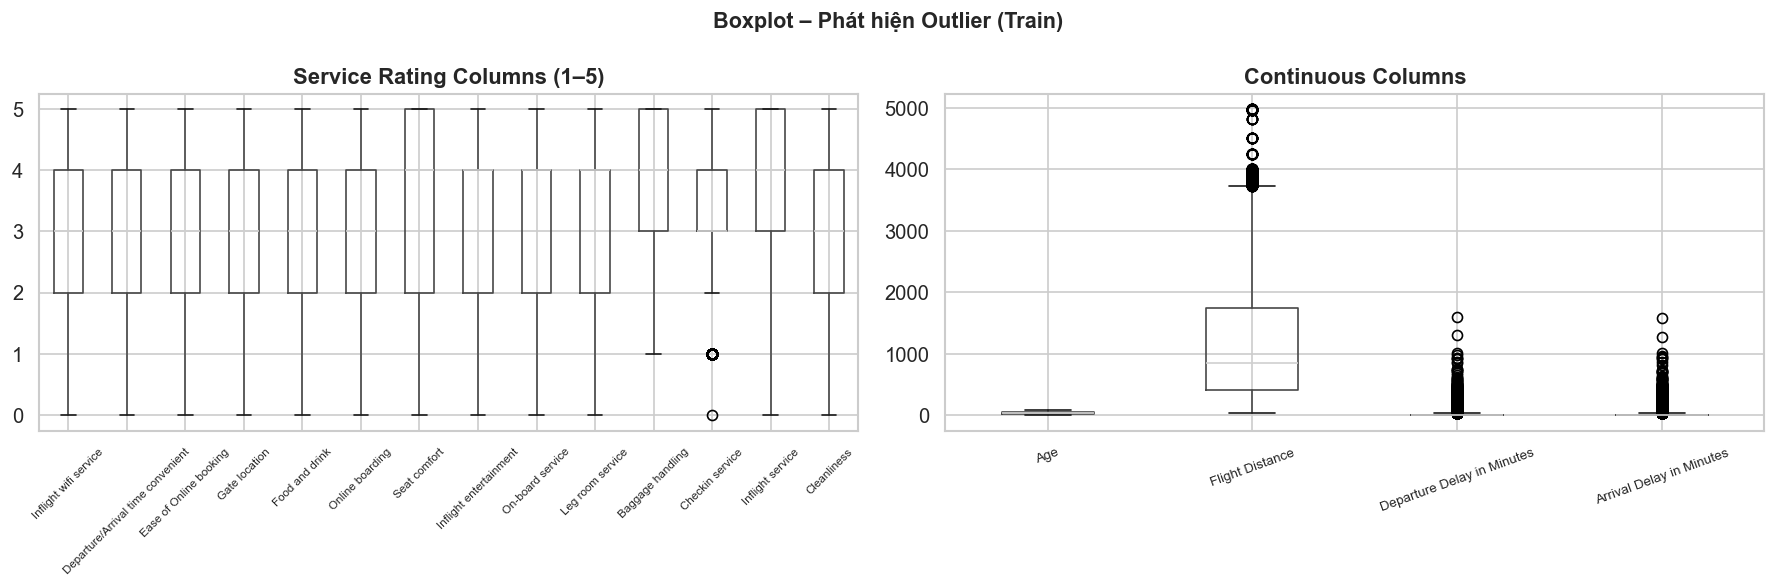

In [13]:
# Boxplot tổng quát
service_rating_cols = [
    'Inflight wifi service', 'Departure/Arrival time convenient',
    'Ease of Online booking', 'Gate location', 'Food and drink',
    'Online boarding', 'Seat comfort', 'Inflight entertainment',
    'On-board service', 'Leg room service', 'Baggage handling',
    'Checkin service', 'Inflight service', 'Cleanliness'
]
delay_num_cols = ['Age', 'Flight Distance',
                  'Departure Delay in Minutes', 'Arrival Delay in Minutes']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

train_df[service_rating_cols].boxplot(ax=axes[0])
axes[0].set_title('Service Rating Columns (1–5)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=7)

train_df[delay_num_cols].boxplot(ax=axes[1])
axes[1].set_title('Continuous Columns', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20, labelsize=8)

plt.suptitle('Boxplot – Phát hiện Outlier (Train)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROC_PATH, '03_boxplot.png'), bbox_inches='tight')
plt.show()

**Nhận xét:**
- Các biến **service rating (1–5)** có phân bố khá đồng đều, tập trung quanh mức 3–4, ít biến động và chỉ xuất hiện một số outlier mức thấp → không ảnh hưởng đáng kể đến mô hình.

- Các biến **liên tục** (đặc biệt *Flight Distance*, *Departure Delay*, *Arrival Delay*) có nhiều outlier và phân bố lệch phải rõ rệt → tiềm ẩn ảnh hưởng đến các mô hình nhạy với dữ liệu.

- **outlier chủ yếu xuất hiện ở các biến liên tục**, trong khi các biến đánh giá dịch vụ tương đối ổn định.

Vì thế cần cân nhắc:
- Scaling cho các biến liên tục  
- Xử lý skew/outlier (log transform hoặc clipping) nếu dùng mô hình tuyến tính

In [14]:
# Đếm số outlier theo IQR cho từng cột
def count_outliers_iqr(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    mask = (series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)
    return mask.sum(), mask.sum() / len(series) * 100

print(f"{'Cột':<40} {'Số outlier':>10} {'Tỉ lệ (%)':>10}")
print('-' * 62)

for col in num_cols:
    n, pct = count_outliers_iqr(train_df[col].dropna())
    if n > 0:
        print(f'{col:<40} {n:>10,} {pct:>9.2f}%')

Cột                                      Số outlier  Tỉ lệ (%)
--------------------------------------------------------------
Flight Distance                               2,291      2.20%
Checkin service                              12,891     12.41%
Departure Delay in Minutes                   14,529     13.98%
Arrival Delay in Minutes                     13,954     13.43%


**Nhận xét:**
- Các biến liên quan đến độ trễ chuyến bay như `Departure Delay in Minutes` (~13.98%) và `Arrival Delay in Minutes` (~13.43%) có tỷ lệ outliers cao, cho thấy phân phối lệch phải mạnh và tồn tại nhiều giá trị cực đoan → cần xử lý bằng **log-transform** để làm mịn dữ liệu.
- Biến `Checkin service` có tỷ lệ outliers tương đối cao (~12.41%), tuy nhiên đây là biến dạng rating rời rạc (1–5) nên các giá trị này không thực sự bất thường → **không cần xử lý outlier**.
- Biến `Flight Distance` có tỷ lệ outliers thấp (~2.20%), cho thấy dữ liệu khá ổn định → **không cần can thiệp thêm**.
- Nhìn chung, chỉ các biến liên quan đến delay cần xử lý outliers, các biến còn lại có thể giữ nguyên để đảm bảo tính toàn vẹn của dữ liệu.

### 2.4 Ma trận tương quan (Correlation Matrix)
Biểu đồ Heatmap cho thấy các biến đánh giá dịch vụ (Inflight wifi, Online boarding...) có tương quan thuận khá rõ ràng với biến mục tiêu.

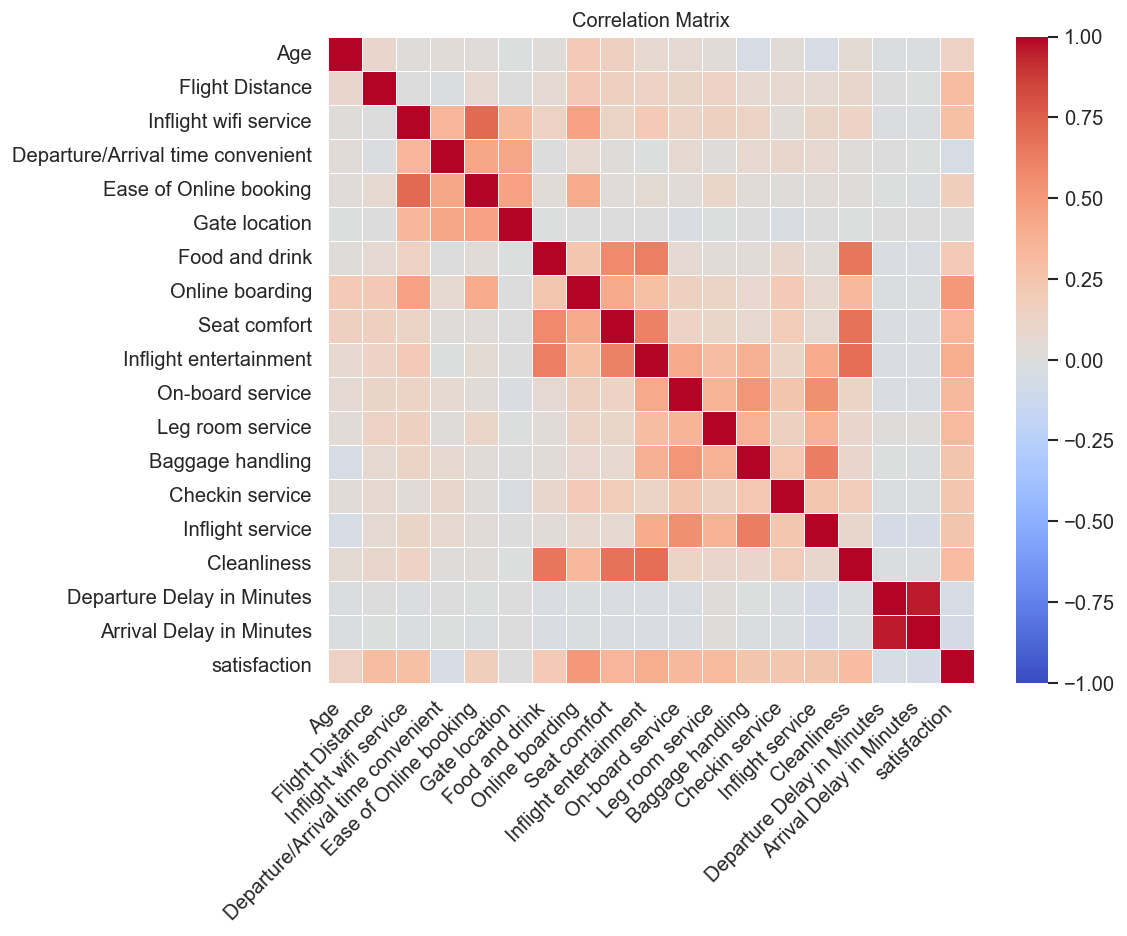

In [15]:
temp_df = train_df.copy()
temp_df[TARGET] = (temp_df[TARGET] == 'satisfied').astype(int)
corr_matrix = temp_df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)

plt.title("Correlation Matrix", fontsize=12)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig(os.path.join(PROC_PATH, '04_correlation_matrix.png'), bbox_inches='tight')
plt.show()

**Nhận xét:**  
Biểu đồ cho thấy phần lớn các biến dịch vụ có tương quan dương với `satisfaction`, nghĩa là khi mức đánh giá dịch vụ tăng thì mức độ hài lòng của hành khách cũng có xu hướng tăng theo.

Ngoài ra, một số cặp biến có tương quan khá cao với nhau, chẳng hạn:
- `Departure Delay in Minutes` và `Arrival Delay in Minutes`
- `Inflight wifi service` và `Ease of Online booking`
- `Cleanliness` và `Inflight entertainment`
- `Seat comfort` và `Cleanliness`

Điều này cho thấy một số đặc trưng trong dataset có xu hướng thay đổi cùng nhau.

#### Outlier detection (IQR)

In [16]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[col] < lower) | (df[col] > upper)]

for col in num_cols:
    outliers = detect_outliers_iqr(train_df, col)
    print(f"{col}: {len(outliers)} outliers")

Age: 0 outliers
Flight Distance: 2291 outliers
Inflight wifi service: 0 outliers
Departure/Arrival time convenient: 0 outliers
Ease of Online booking: 0 outliers
Gate location: 0 outliers
Food and drink: 0 outliers
Online boarding: 0 outliers
Seat comfort: 0 outliers
Inflight entertainment: 0 outliers
On-board service: 0 outliers
Leg room service: 0 outliers
Baggage handling: 0 outliers
Checkin service: 12891 outliers
Inflight service: 0 outliers
Cleanliness: 0 outliers
Departure Delay in Minutes: 14529 outliers
Arrival Delay in Minutes: 13954 outliers


### 2.5 Tương quan với biến mục tiêu – Dịch vụ nào quan trọng nhất?

#### Mối tương quan với Satisfaction - Tất cả đặc trưng 
Để đánh giá mức độ liên hệ giữa từng biến và biến mục tiêu `satisfaction`, hệ số tương quan Pearson được xét riêng theo từng đặc trưng.

In [17]:
corr_with_target = corr_matrix["satisfaction"].sort_values(ascending=False)
corr_with_target

satisfaction                         1.000000
Online boarding                      0.503557
Inflight entertainment               0.398059
Seat comfort                         0.349459
On-board service                     0.322383
Leg room service                     0.313131
Cleanliness                          0.305198
Flight Distance                      0.298780
Inflight wifi service                0.284245
Baggage handling                     0.247749
Inflight service                     0.244741
Checkin service                      0.236174
Food and drink                       0.209936
Ease of Online booking               0.171705
Age                                  0.137167
Gate location                        0.000682
Departure Delay in Minutes          -0.050494
Departure/Arrival time convenient   -0.051601
Arrival Delay in Minutes            -0.057435
Name: satisfaction, dtype: float64

**Nhận xét:**  
Kết quả cho thấy các biến có tương quan dương mạnh nhất với mức độ hài lòng là:
- `Online boarding` (0.5036)
- `Inflight entertainment` (0.3981)
- `Seat comfort` (0.3495)
- `On-board service` (0.3224)
- `Leg room service` (0.3131)
- `Cleanliness` (0.3052)

Ngược lại, các biến độ trễ như `Departure Delay in Minutes` và `Arrival Delay in Minutes` có tương quan âm nhẹ với `satisfaction`, cho thấy chuyến bay bị trễ có xu hướng làm giảm mức độ hài lòng, dù mức liên hệ không mạnh.

#### Mối tương quan với Satisfaction - Các đặc trưng dịch vụ
Xét riêng tương quan giữa các tiêu chí dịch vụ (Service Ratings) và sự hài lòng (Satisfaction):

In [18]:
service_cols = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Inflight service",
    "Cleanliness"
]

service_corr = corr_with_target[service_cols].sort_values(ascending=False)
service_corr

Online boarding                      0.503557
Inflight entertainment               0.398059
Seat comfort                         0.349459
On-board service                     0.322383
Leg room service                     0.313131
Cleanliness                          0.305198
Inflight wifi service                0.284245
Baggage handling                     0.247749
Inflight service                     0.244741
Checkin service                      0.236174
Food and drink                       0.209936
Ease of Online booking               0.171705
Gate location                        0.000682
Departure/Arrival time convenient   -0.051601
Name: satisfaction, dtype: float64

**Nhận xét:**  
Kết quả cho thấy:
- `Online boarding` có tương quan mạnh nhất với mức độ hài lòng
- tiếp theo là `Inflight entertainment`, `Seat comfort` và `On-board service`

Trong khi đó, `Gate location` gần như không có tương quan với `satisfaction` và `Departure/Arrival time convenient` có tương quan âm rất yếu.

Các yếu tố gắn với trải nghiệm dịch vụ trực tiếp của hành khách, đặc biệt là quá trình lên máy bay và các tiện nghi trong chuyến bay, có mối liên hệ rõ rệt nhất với mức độ hài lòng tổng thể.

#### Trực quan hóa mối tương quan giữa các đặc trưng dịch vụ và biến mục tiêu bằng biểu đồ thanh giúp làm nổi bật những yếu tố quan trọng nhất ảnh hưởng đến sự hài lòng của hành khách.

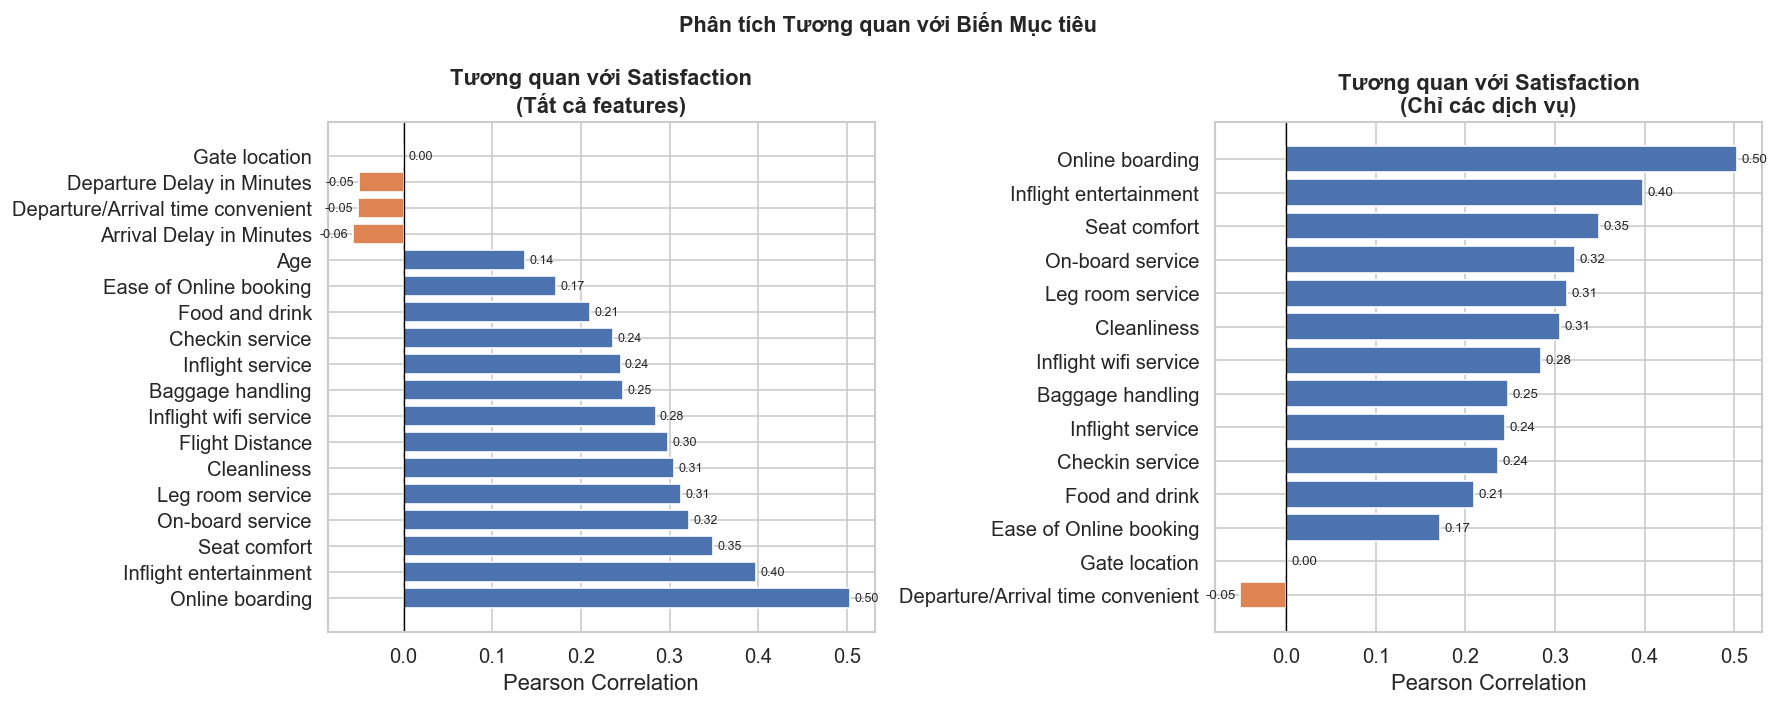

In [19]:
corr_target = corr_matrix[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Tất cả features
colors_all = ['#4C72B0' if v > 0 else '#DD8452' for v in corr_target.values]
bars = axes[0].barh(corr_target.index, corr_target.values, color=colors_all, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Tương quan với Satisfaction\n(Tất cả features)', fontweight='bold')
axes[0].set_xlabel('Pearson Correlation')
for bar, val in zip(bars, corr_target.values):
    axes[0].text(val + (0.005 if val >= 0 else -0.005),
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=7.5)

# Chỉ các cột dịch vụ
svc_corr = corr_target[service_cols].sort_values()
colors_svc = ['#4C72B0' if v > 0 else '#DD8452' for v in svc_corr.values]
bars2 = axes[1].barh(svc_corr.index, svc_corr.values, color=colors_svc, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Tương quan với Satisfaction\n(Chỉ các dịch vụ)', fontweight='bold')
axes[1].set_xlabel('Pearson Correlation')
for bar, val in zip(bars2, svc_corr.values):
    axes[1].text(val + (0.005 if val >= 0 else -0.005),
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=8)

plt.suptitle('Phân tích Tương quan với Biến Mục tiêu', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROC_PATH, '05_correlation_target.png'), bbox_inches='tight')
plt.show()


**Nhận xét:**
- Các biến liên quan đến **chất lượng dịch vụ** có tương quan dương rõ rệt với Satisfaction, trong đó mạnh nhất là *Online boarding*, *Inflight entertainment*, và *Seat comfort* → đây là các yếu tố quan trọng ảnh hưởng đến sự hài lòng.

- Nhóm biến dịch vụ nhìn chung có mức tương quan từ **trung bình đến khá (≈ 0.2–0.5)**, cho thấy chúng có giá trị dự đoán tốt cho mô hình.

- Các biến như **Delay (Departure/Arrival)** có tương quan âm nhẹ → delay càng cao thì mức độ hài lòng càng giảm, nhưng mức ảnh hưởng không quá mạnh.

- Một số biến như *Gate location* hoặc *Departure/Arrival time convenient* có tương quan rất thấp (~0) → đóng góp hạn chế cho việc dự đoán.

Kết luận:
- Nên ưu tiên các biến dịch vụ có tương quan cao cho mô hình  
- Có thể cân nhắc loại bỏ hoặc giảm trọng số các biến tương quan thấp

### 2.6 Scatter plot – Age vs Flight Distance

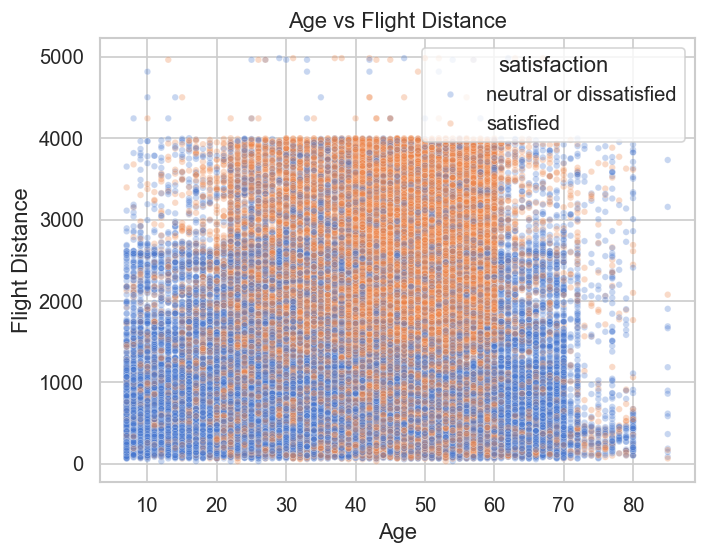

In [20]:
sns.scatterplot(x="Age", y="Flight Distance", hue=TARGET, data=train_df, alpha=0.3, s=15)

plt.title("Age vs Flight Distance")
plt.savefig(os.path.join(PROC_PATH, '06_scatter.png'), bbox_inches='tight')
plt.show()

**Nhận xét:**
 Dữ liệu phân bố khá **rải rác**, không thấy mối quan hệ rõ ràng giữa *Age* và *Flight Distance* → hai biến này gần như **không tương quan mạnh**.

- Hai nhóm *satisfied* và *neutral or dissatisfied* **phân bố chồng lấp nhiều**, không có ranh giới phân tách rõ ràng chỉ dựa trên 2 biến này.

- Mật độ điểm cao ở vùng **khoảng cách bay thấp–trung bình** cho thấy phần lớn chuyến bay có độ dài vừa phải, không phụ thuộc nhiều vào độ tuổi.

**Kết luận:**
- *Age* và *Flight Distance* riêng lẻ **không phải là đặc trưng tốt để phân loại** mức độ hài lòng  
- Cần kết hợp thêm các biến dịch vụ khác để cải thiện khả năng phân lớp

### 2.7 Phân tích phân phối dữ liệu trước và sau log-transform

Kiểm tra phân phối của 2 cột Delay trước và sau khi biến đổi Logarit (Log1p):

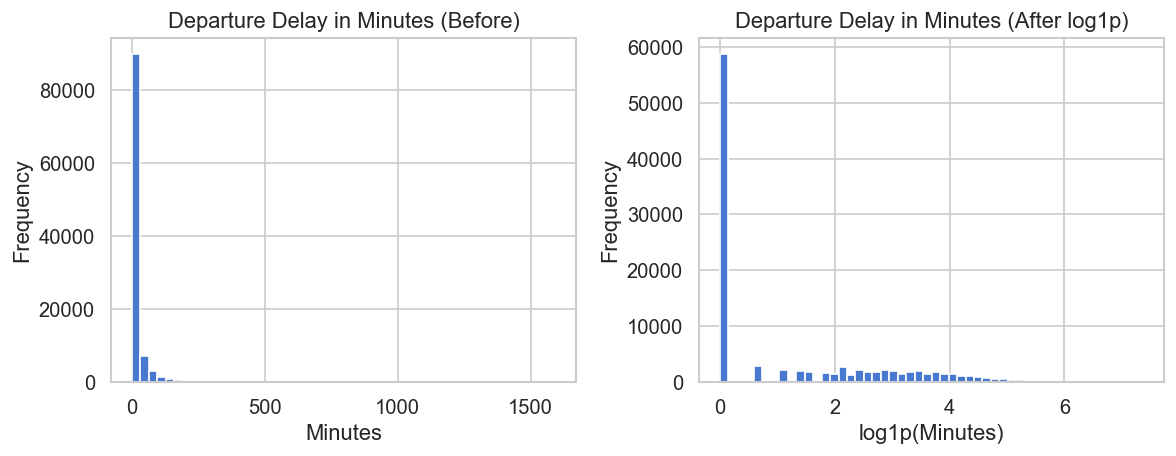

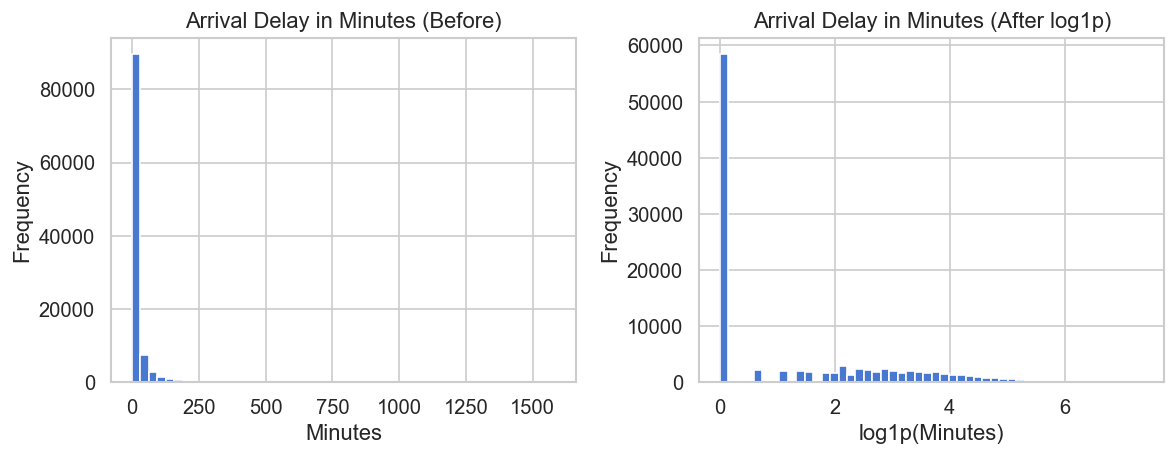

In [21]:
# Histogram trước và sau log-transform cho các cột delay
for col in DELAY_COLS:
    plt.figure(figsize=(10, 4))

    # Trước khi transform
    plt.subplot(1, 2, 1)
    plt.hist(train_df[col].dropna(), bins=50)
    plt.title(f"{col} (Before)")
    plt.xlabel("Minutes")
    plt.ylabel("Frequency")

    # Sau khi transform
    plt.subplot(1, 2, 2)
    plt.hist(np.log1p(train_df[col].dropna()), bins=50)
    plt.title(f"{col} (After log1p)")
    plt.xlabel("log1p(Minutes)")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

**Nhận xét:**
- Dữ liệu ban đầu lệch phải mạnh và chứa nhiều outliers.
- Sau log-transform, phân phối trở nên cân đối hơn và giảm ảnh hưởng của các giá trị lớn.
- Việc này giúp cải thiện chất lượng đầu vào cho mô hình.

## Phân tích tương quan
### Ma trận tương quan
Nhóm tính ma trận tương quan Pearson trên các biến định lượng để tìm mối quan hệ tuyến tính. Trước đó, biến satisfaction đã được chuyển sang dạng nhị phân (0-1), trong đó:
- `neutral or dissatisfied` = 0
- `satisfied` = 1

In [22]:
# Ma trận tương quan
corr_matrix = train_df.select_dtypes(include=["number"]).corr()
corr_matrix

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
Age,1.000000,0.099461,0.017859,0.038125,0.024842,-0.001330,0.023000,0.208939,0.160277,0.076444,0.057594,0.040583,-0.047529,0.035482,-0.049427,0.053611,-0.010152,-0.012105
Flight Distance,0.099461,1.000000,0.007131,-0.020043,0.065717,0.004793,0.056994,0.214869,0.157333,0.128740,0.109526,0.133916,0.063184,0.073072,0.057540,0.093149,0.002158,-0.002470
Inflight wifi service,0.017859,0.007131,1.000000,0.343845,0.715856,0.336248,0.134718,0.456970,0.122658,0.209321,0.121500,0.160473,0.120923,0.043193,0.110441,0.132698,-0.017402,-0.019042
Departure/Arrival time convenient,0.038125,-0.020043,0.343845,1.000000,0.436961,0.444757,0.004906,0.070119,0.011344,-0.004861,0.068882,0.012441,0.072126,0.093333,0.073318,0.014292,0.001005,-0.000918
Ease of Online booking,0.024842,0.065717,0.715856,0.436961,1.000000,0.458655,0.031873,0.404074,0.030014,0.047032,0.038833,0.107601,0.038762,0.011081,0.035272,0.016179,-0.006371,-0.007947
Gate location,-0.001330,0.004793,0.336248,0.444757,0.458655,1.000000,-0.001159,0.001688,0.003669,0.003517,-0.028373,-0.005873,0.002313,-0.035427,0.001681,-0.003830,0.005467,0.005178
Food and drink,0.023000,0.056994,0.134718,0.004906,0.031873,-0.001159,1.000000,0.234468,0.574556,0.622512,0.059073,0.032498,0.034746,0.087299,0.033993,0.657760,-0.029926,-0.032466
Online boarding,0.208939,0.214869,0.456970,0.070119,0.404074,0.001688,0.234468,1.000000,0.420211,0.285066,0.155443,0.123950,0.083280,0.204462,0.074573,0.331517,-0.018982,-0.021874
Seat comfort,0.160277,0.157333,0.122658,0.011344,0.030014,0.003669,0.574556,0.420211,1.000000,0.610590,0.131971,0.105559,0.074542,0.191854,0.069218,0.678534,-0.027898,-0.029735
Inflight entertainment,0.076444,0.128740,0.209321,-0.004861,0.047032,0.003517,0.622512,0.285066,0.610590,1.000000,0.420153,0.299692,0.378210,0.120867,0.404855,0.691815,-0.027489,-0.030597


**Nhận xét:**  
Biểu đồ cho thấy phần lớn các biến dịch vụ có tương quan dương với `satisfaction`, nghĩa là khi mức đánh giá dịch vụ tăng thì mức độ hài lòng của hành khách cũng có xu hướng tăng theo.

Ngoài ra, một số cặp biến có tương quan khá cao với nhau, chẳng hạn:
- `Departure Delay in Minutes` và `Arrival Delay in Minutes`
- `Inflight wifi service` và `Ease of Online booking`
- `Cleanliness` và `Inflight entertainment`
- `Seat comfort` và `Cleanliness`

Điều này cho thấy một số đặc trưng trong dataset có xu hướng thay đổi cùng nhau.

---
## 3. Mã hóa & Xử lý Outliers
> **Nguyên tắc No Data Leakage:**  
> Mọi tham số (median, encoder mapping, scaler) đều **fit trên train only**, sau đó **transform** lên val và test.

### 3.1 Encode biến phân loại & biến mục tiêu

In [23]:
def encode_features(df, is_train=True, encoders=None):
    df = df.copy()

    df[TARGET] = (df[TARGET] == 'satisfied').astype(int)

    # Label Encoding (binary)
    # Lưu từng encoder riêng → có thể inverse_transform sau này
    binary_cols = ['Gender', 'Customer Type', 'Type of Travel']
    if is_train:
        encoders = {}
        for col in binary_cols:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])   # fit + transform trên train
            encoders[col] = le
    else:
        for col in binary_cols:
            df[col] = encoders[col].transform(df[col])  # chỉ transform trên test

    # One-Hot Encoding: Class
    df = pd.get_dummies(df, columns=['Class'], prefix='Class', drop_first=False, dtype=int)
    for col in ['Class_Business', 'Class_Eco', 'Class_Eco Plus']:
        if col not in df.columns:
            df[col] = 0

    return df, encoders


train_enc, LE_ENCODERS = encode_features(train_df, is_train=True)
test_enc,  _           = encode_features(test_df,  is_train=False, encoders=LE_ENCODERS)

print(f'Train encoded: {train_enc.shape} | Test encoded: {test_enc.shape}')
print(f'satisfaction unique: {sorted(train_enc[TARGET].unique())}')
print()
print('Label Encoding mapping:')
for col, le in LE_ENCODERS.items():
    print(f'  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')
print()
print('Columns sau encoding:', list(train_enc.columns))

Train encoded: (103904, 25) | Test encoded: (25976, 25)
satisfaction unique: [np.int64(0), np.int64(1)]

Label Encoding mapping:
  Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
  Customer Type: {'Loyal Customer': np.int64(0), 'disloyal Customer': np.int64(1)}
  Type of Travel: {'Business travel': np.int64(0), 'Personal Travel': np.int64(1)}

Columns sau encoding: ['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction', 'Class_Business', 'Class_Eco', 'Class_Eco Plus']


### 3.2 Kiểm tra Outlier cột Delay – trước và sau Log-transform

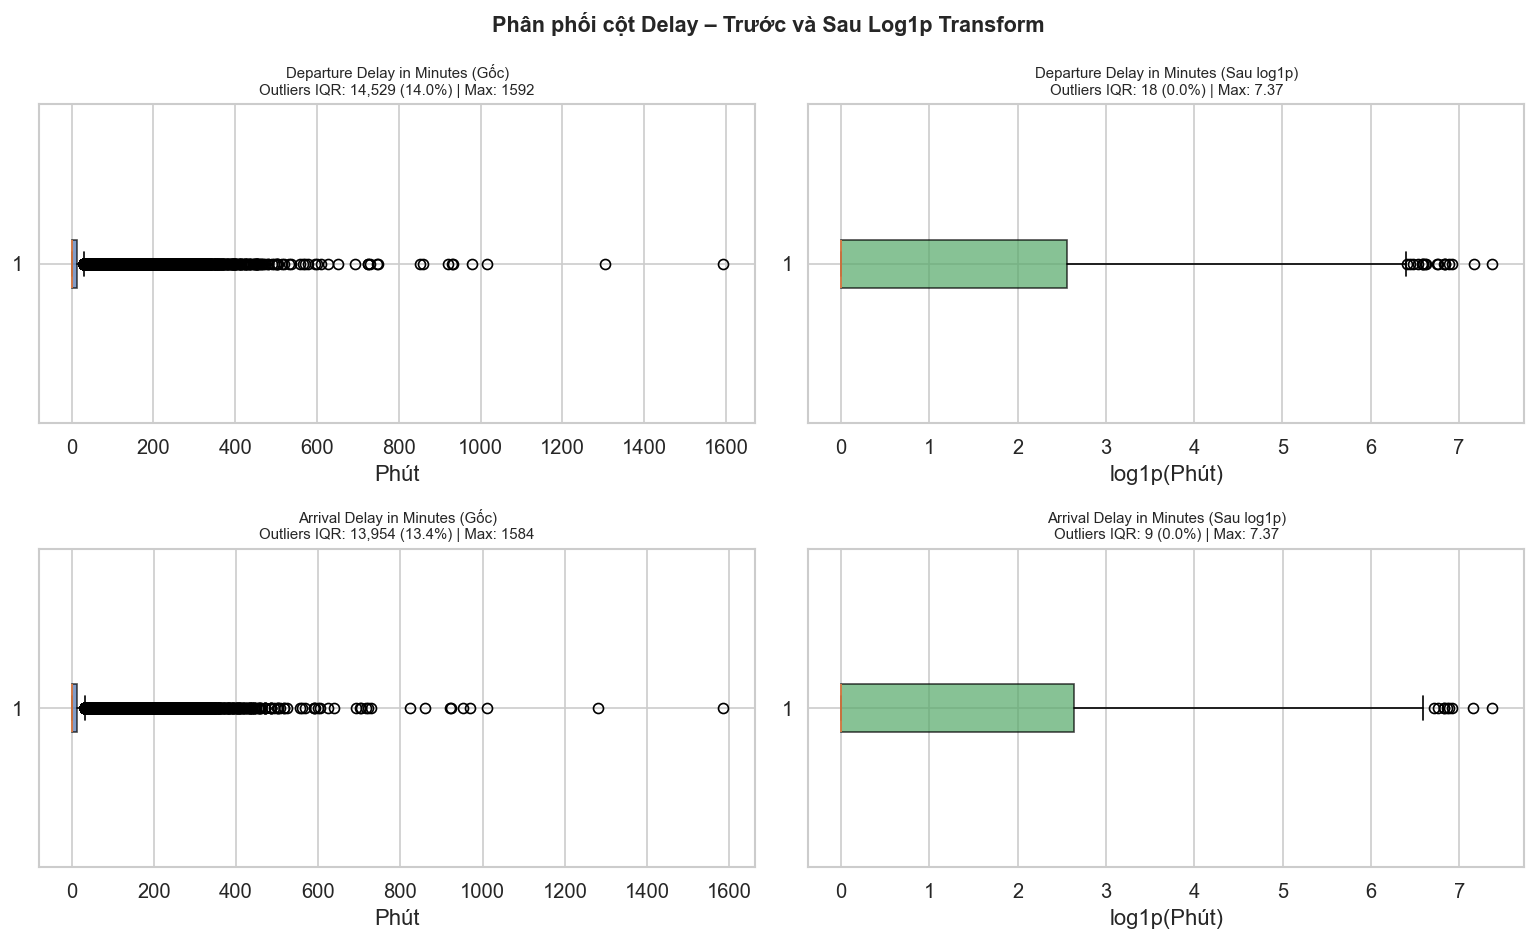

In [24]:
# DELAY_COLS = ['Departure Delay in Minutes', 'Arrival Delay in Minutes'] đã define ở trên

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Phân phối cột Delay – Trước và Sau Log1p Transform',
             fontweight='bold', fontsize=13)

for i, col in enumerate(DELAY_COLS):
    data = train_enc[col]
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    n_out = ((data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)).sum()

    # Trước transform
    axes[i, 0].boxplot(data, vert=False, patch_artist=True,
                       boxprops=dict(facecolor='#4C72B0', alpha=0.7))
    axes[i, 0].set_title(
        f'{col} (Gốc)\nOutliers IQR: {n_out:,} ({n_out/len(data):.1%}) | Max: {data.max():.0f}',
        fontsize=9)
    axes[i, 0].set_xlabel('Phút')

    # Sau log1p
    log_data = np.log1p(data)
    q1l, q3l = log_data.quantile(0.25), log_data.quantile(0.75)
    iqrl = q3l - q1l
    n_out_l = ((log_data < q1l - 1.5*iqrl) | (log_data > q3l + 1.5*iqrl)).sum()

    axes[i, 1].boxplot(log_data, vert=False, patch_artist=True,
                       boxprops=dict(facecolor='#55A868', alpha=0.7))
    axes[i, 1].set_title(
        f'{col} (Sau log1p)\nOutliers IQR: {n_out_l:,} ({n_out_l/len(log_data):.1%}) | Max: {log_data.max():.2f}',
        fontsize=9)
    axes[i, 1].set_xlabel('log1p(Phút)')

plt.tight_layout()
plt.savefig(os.path.join(PROC_PATH, '07_delay_outlier.png'), bbox_inches='tight')
plt.show()

**Nhận xét**

- Trước biến đổi: dữ liệu **lệch phải mạnh**, nhiều outliers (~14%), giá trị lớn gây méo phân phối.  
- Sau log1p: phân phối **cân đối hơn**, outliers gần như biến mất, dữ liệu dễ quan sát hơn.  

**Kết luận:** Log1p giúp giảm skewness và ảnh hưởng của outliers, nên phù hợp để sử dụng cho bước huấn luyện mô hình.

### Log Transformation (log1p) cho các biến Delay

Áp dụng biến đổi `log1p(x) = log(1 + x)` cho các biến:
- Departure Delay in Minutes  
- Arrival Delay in Minutes  

In [25]:
# Áp dụng log1p transform
# log1p(x) = log(1+x). An toàn khi x=0, không cần fit vì không có tham số học từ data
for col in DELAY_COLS:
    skew_b = train_enc[col].skew()
    train_enc[col] = np.log1p(train_enc[col])
    test_enc[col]  = np.log1p(test_enc[col])
    skew_a = train_enc[col].skew()
    print(f'log1p({col}): skewness {skew_b:.2f} → {skew_a:.2f}')

log1p(Departure Delay in Minutes): skewness 6.73 → 0.92
log1p(Arrival Delay in Minutes): skewness 6.61 → 0.88


**Nhận xét:**
- Trước khi biến đổi, các biến delay có **độ lệch phải rất lớn (skewness > 6)** do tồn tại nhiều giá trị cực lớn (outlier).

- Sau khi áp dụng log1p, skewness giảm mạnh xuống **< 1**, cho thấy phân bố đã trở nên **cân đối hơn và gần chuẩn hơn**.

- Biến đổi này giúp:
  - Giảm ảnh hưởng của outlier  
  - Cải thiện hiệu quả cho các mô hình nhạy với phân phối dữ liệu (Logistic Regression, SVM)

**Kết luận:**  
Log1p là bước tiền xử lý hiệu quả, giúp ổn định dữ liệu và nâng cao khả năng học của mô hình.

#### Cắt tỉa các cột liên tục chưa log-transform

In [26]:
# Chỉ cắt tỉa các cột liên tục chưa log-transform
cols_to_clip = ['Flight Distance'] 

for col in cols_to_clip:
    Q1 = train_enc[col].quantile(0.25)
    Q3 = train_enc[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Dùng ngưỡng của Train để cắt cho cả Train và Test
    train_enc[col] = train_enc[col].clip(lower=lower_bound, upper=upper_bound)
    test_enc[col]  = test_enc[col].clip(lower=lower_bound, upper=upper_bound)

print(f"✓ Đã cắt tỉa Outlier cho cột {cols_to_clip} thành công!")

✓ Đã cắt tỉa Outlier cho cột ['Flight Distance'] thành công!


In [27]:
# Hàm kiểm tra kết quả cắt tỉa
def check_clipping_result(df, columns, dataset_name="Data"):
    print(f"--- Kiểm tra trên tập {dataset_name} ---")
    print(f"{'Cột':<25} | {'Min':<10} | {'Max':<10} | {'Số Outlier hiện tại'}")
    print("-" * 70)
    
    for col in columns:
        data = df[col].dropna()
        
        # Tính toán lại ranh giới IQR
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Đếm số outlier
        outliers_count = ((data < lower_bound) | (data > upper_bound)).sum()
        
        print(f"{col:<25} | {data.min():<10.2f} | {data.max():<10.2f} | {outliers_count}")
    print("\n")

# Gọi hàm kiểm tra cho cả tập Train và Test
check_clipping_result(train_enc, cols_to_clip, "TRAIN")
check_clipping_result(test_enc, cols_to_clip, "TEST")

--- Kiểm tra trên tập TRAIN ---
Cột                       | Min        | Max        | Số Outlier hiện tại
----------------------------------------------------------------------
Flight Distance           | 31.00      | 3736.50    | 0


--- Kiểm tra trên tập TEST ---
Cột                       | Min        | Max        | Số Outlier hiện tại
----------------------------------------------------------------------
Flight Distance           | 31.00      | 3736.50    | 0




---
## 4. Chia dữ liệu & Chuẩn hóa

### 4.1 Train / Validation / Test split
- `train.csv` (~80% tổng) chia 87.5% / 12.5% → **Train 70%** / **Val 10%**  
- `test.csv` (~20% tổng) dùng thẳng làm **Test set**  
- `stratify=y` đảm bảo tỉ lệ lớp nhất quán giữa các tập

### 4.1 Chia dữ liệu train/validation/test
Nhóm sẽ chia `train.csv` theo tỉ lệ `87.5% / 12.5%` để tạo ra tập `train` và `validation`.  
Kết hợp với `test.csv` có sẵn, ta thu được tỉ lệ tổng thể khoảng `70% / 10% / 20%`.

In [28]:
# Tách đặc trưng (X) và nhãn (y) từ tập đã được ENCODE + LOG-TRANSFORM
FEATURE_COLS = [c for c in train_enc.columns if c != TARGET]

X_full  = train_enc[FEATURE_COLS].copy()
y_full  = train_enc[TARGET].copy()
X_test  = test_enc[FEATURE_COLS].copy()
y_test  = test_enc[TARGET].copy()

# Cố định random_state để kết quả chia dữ liệu có thể lặp lại
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full,
    test_size=0.125,
    random_state=SEED,
    stratify=y_full
)

total_samples = len(X_train) + len(X_val) + len(X_test)
print('Kích thước các tập dữ liệu:')
print(f'  X_train ({len(X_train)/total_samples:.1%}): {X_train.shape}')
print(f'  X_val   ({len(X_val)/total_samples:.1%}):  {X_val.shape}')
print(f'  X_test  ({len(X_test)/total_samples:.1%}): {X_test.shape}')
print()
print(f'y_train unique: {sorted(y_train.unique())}  (phải là [0, 1])')
print(f'y_train value_counts:\n{y_train.value_counts().sort_index()}')

Kích thước các tập dữ liệu:
  X_train (70.0%): (90916, 24)
  X_val   (10.0%):  (12988, 24)
  X_test  (20.0%): (25976, 24)

y_train unique: [np.int64(0), np.int64(1)]  (phải là [0, 1])
y_train value_counts:
satisfaction
0    51519
1    39397
Name: count, dtype: int64


## 4.2 Chuẩn hóa dữ liệu bằng StandardScaler

Nhóm sử dụng `StandardScaler` để đưa các thuộc tính số như `Age`, `Flight Distance`, ... về cùng thang đo.  
Scaler chỉ được `fit` trên tập train và sau đó áp dụng cho validation/test để tránh data leakage.

In [29]:
# Loại các cột OHE (Class_*) và binary 0/1 ra khỏi danh sách cần scale
# Chỉ scale cột liên tục có > 2 giá trị phân biệt
ohe_cols   = [c for c in FEATURE_COLS if c.startswith('Class_')]
SCALE_COLS = [c for c in FEATURE_COLS
              if X_train[c].nunique() > 2 and c not in ohe_cols]

print('Các cột được scale:')
print(SCALE_COLS)
print()

scaler = StandardScaler()

x_train_scaled = X_train.copy()
x_val_scaled   = X_val.copy()
x_test_scaled  = X_test.copy()

x_train_scaled[SCALE_COLS] = scaler.fit_transform(X_train[SCALE_COLS])
x_val_scaled[SCALE_COLS]   = scaler.transform(X_val[SCALE_COLS])
x_test_scaled[SCALE_COLS]  = scaler.transform(X_test[SCALE_COLS])

# Kiểm tra: mean ≈ 0, std ≈ 1 trên tập train
check = x_train_scaled[SCALE_COLS].agg(['mean', 'std']).round(4).T
check.columns = ['mean (≈0)', 'std (≈1)']
display(check)

# Kiểm tra satisfaction KHÔNG bị ảnh hưởng bởi scaling
print(f'\ny_train unique sau scale: {sorted(y_train.unique())}  (vẫn phải là [0, 1])')

Các cột được scale:
['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']



,mean (≈0),std (≈1)
Age,0.0,1.0
Flight Distance,0.0,1.0
Inflight wifi service,-0.0,1.0
Departure/Arrival time convenient,-0.0,1.0
Ease of Online booking,-0.0,1.0
Gate location,0.0,1.0
Food and drink,-0.0,1.0
Online boarding,-0.0,1.0
Seat comfort,0.0,1.0
Inflight entertainment,-0.0,1.0



y_train unique sau scale: [np.int64(0), np.int64(1)]  (vẫn phải là [0, 1])


**Nhận xét:**
- Việc chuẩn hóa giúp các biến có cùng thang đo, tránh việc các biến có giá trị lớn (như *Flight Distance*, *Delay*) chi phối mô hình.

- Đặc biệt quan trọng đối với các mô hình:
  - Logistic Regression  
  - SVM  
  - KNN  

- Các biến đánh giá dịch vụ (1–5) sau khi scale sẽ **phù hợp hơn khi học trọng số**, dù ban đầu là dạng ordinal.

**Kết luận:**  
Chuẩn hóa là bước cần thiết giúp mô hình hội tụ nhanh hơn và cải thiện hiệu năng tổng thể.

## 4.3 Kiểm tra mất cân bằng lớp

Kiểm tra tỉ lệ giữa hai lớp `neutral or dissatisfied` và `satisfied` trên các tập train, validation, test.  
Biểu đồ cột được sử dụng để quan sát mức độ chênh lệch số lượng mẫu giữa các lớp.

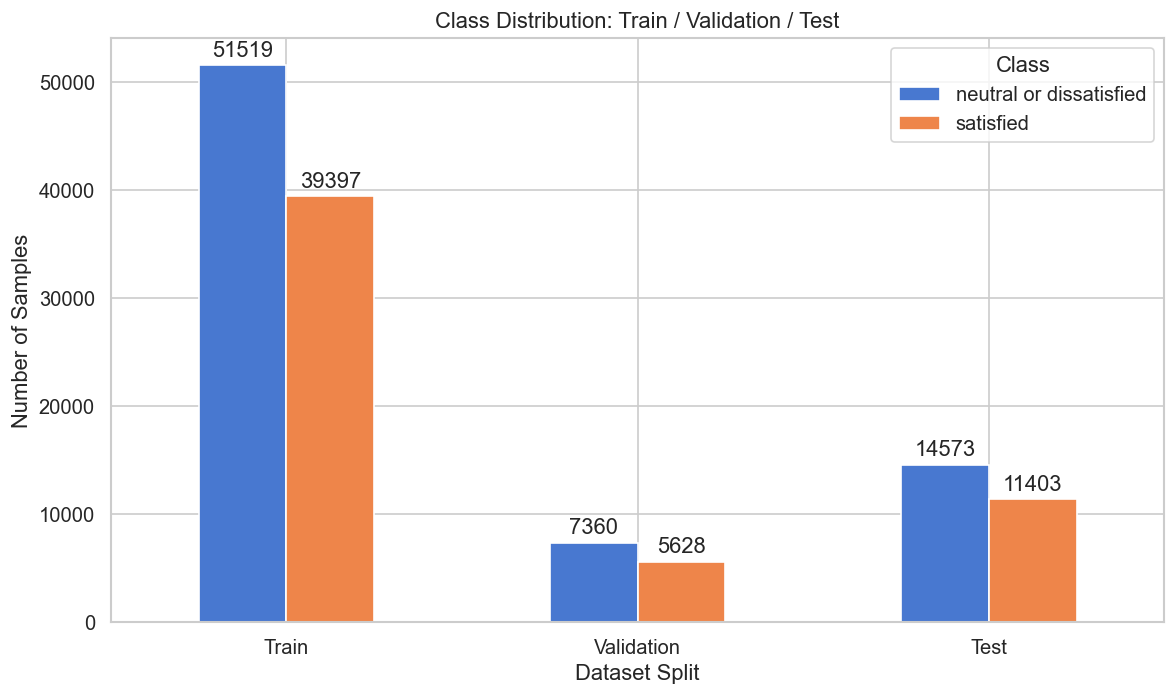

In [30]:
# Hàm tính số lượng mẫu, tỉ lệ phần trăm và hệ số mất cân bằng của từng lớp
def get_class_distribution(y):
    y = y.copy()

    if y.dtype == "object":
        y = y.map({
            "neutral or dissatisfied": 0,
            "satisfied": 1
        })

    counts = y.value_counts().sort_index()
    ratios = y.value_counts(normalize=True).sort_index() * 100
    imbalance_ratio = counts.max() / counts.min()

    return counts, ratios, imbalance_ratio


# Lấy thông tin phân bố lớp trên từng tập
train_counts, train_ratios, train_ir = get_class_distribution(y_train)
val_counts, val_ratios, val_ir = get_class_distribution(y_val)
test_counts, test_ratios, test_ir = get_class_distribution(y_test)

# Gộp số lượng mẫu của các lớp vào một DataFrame để tiện vẽ biểu đồ
dist_df = pd.DataFrame({
    "Train": train_counts,
    "Validation": val_counts,
    "Test": test_counts
}).fillna(0)

# Vẽ biểu đồ cột so sánh phân bố lớp giữa các tập dữ liệu
ax = dist_df.T.plot(kind="bar", figsize=(10, 6))

plt.title("Class Distribution: Train / Validation / Test")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.legend(title="Class", labels=["neutral or dissatisfied", "satisfied"])

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

**Nhận xét**

- Tỷ lệ giữa hai lớp (`neutral or dissatisfied` và `satisfied`) tương đối cân bằng ở cả train, validation và test.  
- Phân phối giữa các tập gần như giống nhau → việc **stratified split hoạt động tốt**.  

**Kết luận:** Dữ liệu không bị mất cân bằng nghiêm trọng và đảm bảo tính nhất quán giữa các tập, phù hợp cho huấn luyện và đánh giá mô hình.

Dữ liệu mất cân bằng nhẹ (Tỉ lệ 1.3:1), nên nhóm quyết định tính trước class_weight để dự phòng truyền vào hàm Loss khi train model

## 4.4 Nhận xét về weighted loss

Dựa trên tỉ lệ phân bố lớp, nhóm đánh giá xem dữ liệu có bị mất cân bằng đáng kể hay không?  
Nếu mức chênh lệch lớn, có thể cân nhắc sử dụng `weighted loss` khi huấn luyện mô hình.


In [31]:
# In tỉ lệ mất cân bằng và nhận xét về mức độ mất cân bằng của dữ liệu
def imbalance_comment(imbalance_ratio):
    if imbalance_ratio < 1.5:
        return "Dữ liệu khá cân bằng, chưa cần weighted loss."
    elif imbalance_ratio < 2.0:
        return "Dữ liệu lệch nhẹ, nên thử weighted loss để so sánh."
    else:
        return "Dữ liệu lệch đáng kể, nên sử dụng weighted loss."

print(imbalance_comment(train_ir))

Dữ liệu khá cân bằng, chưa cần weighted loss.


In [32]:
# Tính class weights để truyền vào model
n_total = len(y_train)
class_counts_train = y_train.value_counts().sort_index()

CLASS_WEIGHTS = {}
for cls, cnt in class_counts_train.items():
    CLASS_WEIGHTS[cls] = n_total / (2 * cnt)

print('Class weights để cân bằng mất cân bằng:')
for cls, w in CLASS_WEIGHTS.items():
    lbl = 'neutral/dissatisfied' if cls == 0 else 'satisfied'
    print(f'  Class {cls} ({lbl}): w = {w:.4f}')
print()

# Quyết định có cần weighted loss không
if train_ir < 1.5:
    decision = 'Mất cân bằng nhẹ (<1.5:1). Dùng class_weight=\'balanced\' là đủ.'
elif train_ir < 3.0:
    decision = 'Mất cân bằng vừa. NÊN dùng class_weight hoặc SMOTE.'
else:
    decision = 'Mất cân bằng nặng. CẦN resampling hoặc class_weight.'

print(f'IR = {train_ir:.3f} → {decision}')

Class weights để cân bằng mất cân bằng:
  Class 0 (neutral/dissatisfied): w = 0.8824
  Class 1 (satisfied): w = 1.1538

IR = 1.308 → Mất cân bằng nhẹ (<1.5:1). Dùng class_weight='balanced' là đủ.


---
## Tổng kết & Lưu dữ liệu đã xử lý

In [33]:
# Lưu dữ liệu đã xử lý vào file pickle để sử dụng cho phần modeling
MEDIAN_ARRIVAL = train_df['Arrival Delay in Minutes'].median()
FEATURE_COLS = [c for c in train_enc.columns if c != TARGET]
num_cols = X_train.select_dtypes(include=np.number).columns

SCALE_COLS = [
    c for c in num_cols
    if X_train[c].nunique() > 2
]
processed = {
    'X_train': x_train_scaled,  'y_train': y_train,
    'X_val':   x_val_scaled,    'y_val':   y_val,
    'X_test':  x_test_scaled,   'y_test':  y_test,
    'scaler':        scaler,
    'le_encoders':   LE_ENCODERS,
    'class_weights': CLASS_WEIGHTS,
    'feature_cols':  FEATURE_COLS,
    'scale_cols':    SCALE_COLS,
    'delay_cols':    DELAY_COLS,
    'median_arrival': MEDIAN_ARRIVAL,
    'seed':          SEED,
}
with open(PKL_PATH, 'wb') as f:
    pickle.dump(processed, f)
print(f'✓ Đã lưu: {PKL_PATH}')

# Lưu thông tin preprocessing vào file JSON để tham khảo sau này
info = {
    'split': {'train': len(x_train_scaled), 'val': len(x_val_scaled), 'test': len(x_test_scaled)},
    'label_encoders': {col: {'classes': le.classes_.tolist()}
                       for col, le in LE_ENCODERS.items()},
    'median_arrival_delay': float(MEDIAN_ARRIVAL),
    'class_weights': {str(k): float(v) for k, v in CLASS_WEIGHTS.items()},
    'scale_cols': SCALE_COLS,
    'delay_log_transform_cols': DELAY_COLS,
    'seed': SEED,
}
with open(INFO_PATH, 'w', encoding='utf-8') as f:
    json.dump(info, f, indent=2, ensure_ascii=False)
print(f'✓ Đã lưu: {INFO_PATH}')

# Lưu dữ liệu đã xử lý vào file CSV
train_out = os.path.join(PROC_DATA_PATH, 'train_processed.csv')
test_out  = os.path.join(PROC_DATA_PATH, 'test_processed.csv')
try:
    pd.concat([x_train_scaled, y_train], axis=1).to_csv(train_out, index=False)
    pd.concat([x_test_scaled, y_test], axis=1).to_csv(test_out, index=False)
    print(f'✓ Đã lưu: train_processed.csv, test_processed.csv')
except PermissionError:
    print("LỖI QUYỀN TRUY CẬP: Bạn đang mở file CSV này bằng phần mềm khác")
    print("Hãy ĐÓNG file đó lại và chạy lại Cell này!")

✓ Đã lưu: d:\2025-2026 HKII\Machine Learning\Project1\Machine-Learning---Project-1-\data\processed\processed_data.pkl
✓ Đã lưu: d:\2025-2026 HKII\Machine Learning\Project1\Machine-Learning---Project-1-\data\processed\preprocessing_info.json
✓ Đã lưu: train_processed.csv, test_processed.csv
